# Section 4: Ransomware Detection and Prevention

This experiment uses ordered Windows API-call sequences to compare a class-balanced linear SVM with a class-weighted LSTM. Only ransomware and goodware records are retained from the multiclass source dataset.

In [1]:
import os
import sys

if "google.colab" in sys.modules:
    os.chdir("/content")

In [2]:
%pip install -q joblib matplotlib numpy pandas scikit-learn torch

In [5]:
import json
import random
import shutil
import urllib.request
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
LSTM_EPOCHS = 1  # Change to 1 for a quick pipeline check.
COLAB = "google.colab" in sys.modules
ROOT = Path("/content/section_04_workspace") if COLAB else Path.cwd()
DATA_FILE = ROOT / "data/raw/ransomware-api/multiclass_malware_api_seq.csv"
PROCESSED_DIR = ROOT / "data/processed/section_04"
MODELS_DIR = ROOT / "models/section_04"
RESULTS_DIR = ROOT / "reports/section_04"

for directory in (DATA_FILE.parent, PROCESSED_DIR, MODELS_DIR, RESULTS_DIR / "metrics", RESULTS_DIR / "figures"):
    directory.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Download and profile the API sequences

In [4]:
DATA_URL = "https://zenodo.org/records/16742661/files/multiclass_malware_api_seq.csv?download=1"
if not DATA_FILE.exists():
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

,value
source_records,41476
selected_records,1374
missing_values,0
duplicate_sequences,744
records_after_cleaning,630
goodware,591
ransomware,39
unique_api_calls,210


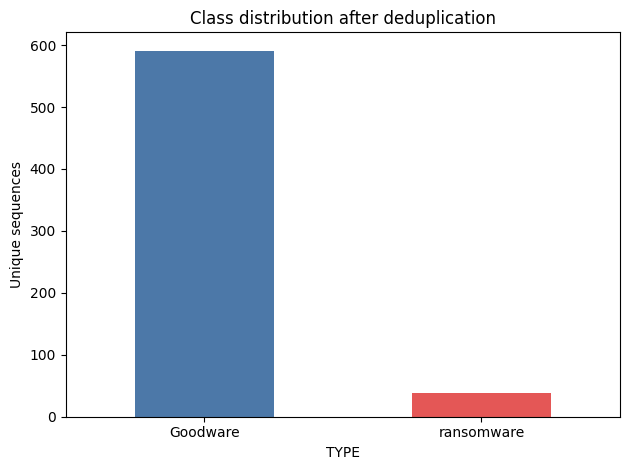

In [6]:
raw = pd.read_csv(DATA_FILE)
selected = raw.loc[raw["TYPE"].isin(["Goodware", "ransomware"]), ["APISEQ", "TYPE"]].copy()
profile = {
    "source_records": len(raw),
    "selected_records": len(selected),
    "missing_values": int(selected.isna().sum().sum()),
    "duplicate_sequences": int(selected["APISEQ"].duplicated().sum()),
}

data = selected.dropna().drop_duplicates("APISEQ").reset_index(drop=True)
data.insert(0, "sequence_id", range(len(data)))
data["label"] = data["TYPE"].eq("ransomware").astype(int)
data["sequence_length"] = data["APISEQ"].str.split().str.len()
profile.update({
    "records_after_cleaning": len(data),
    "goodware": int((data["label"] == 0).sum()),
    "ransomware": int((data["label"] == 1).sum()),
    "unique_api_calls": len(set(" ".join(data["APISEQ"]).split())),
})
(PROCESSED_DIR / "data-profile.json").write_text(json.dumps(profile, indent=2))
display(pd.Series(profile).to_frame("value"))

class_counts = data["TYPE"].value_counts().reindex(["Goodware", "ransomware"])
class_counts.plot.bar(color=["#4C78A8", "#E45756"], rot=0, ylabel="Unique sequences", title="Class distribution after deduplication")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures/class-distribution.png", dpi=180)
plt.show()

Exact duplicate sequences are removed before splitting to prevent identical behavior traces from appearing in both training and test data. This leaves a small ransomware class, which limits how stable the final estimates can be.

## 2. Create shared train, validation, and test splits

In [7]:
train_validation, test = train_test_split(
    data, test_size=0.15, stratify=data["label"], random_state=SEED,
)
train, validation = train_test_split(
    train_validation, test_size=0.15 / 0.85,
    stratify=train_validation["label"], random_state=SEED,
)
train, validation, test = [frame.reset_index(drop=True) for frame in (train, validation, test)]

manifest = pd.concat([
    frame[["sequence_id", "TYPE", "label"]].assign(split=name)
    for name, frame in (("train", train), ("validation", validation), ("test", test))
], ignore_index=True)
manifest.to_csv(PROCESSED_DIR / "split-manifest.csv", index=False)
display(pd.crosstab(manifest["split"], manifest["TYPE"]))

TYPE,Goodware,ransomware
split,,
test,89,6
train,413,27
validation,89,6


## 3. Shared evaluation

In [8]:
def evaluate(name, labels, probabilities, filename):
    predictions = (probabilities >= 0.5).astype(int)
    metrics = {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision_score(labels, predictions, zero_division=0)),
        "recall": float(recall_score(labels, predictions, zero_division=0)),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(labels, probabilities)),
        "average_precision": float(average_precision_score(labels, probabilities)),
        "confusion_matrix": confusion_matrix(labels, predictions).tolist(),
        "classification_report": classification_report(
            labels, predictions, target_names=["goodware", "ransomware"],
            output_dict=True, zero_division=0,
        ),
    }
    (RESULTS_DIR / "metrics" / f"{filename}.json").write_text(json.dumps(metrics, indent=2))

    figure, axes = plt.subplots(1, 3, figsize=(15, 4))
    ConfusionMatrixDisplay.from_predictions(
        labels, predictions, display_labels=["Goodware", "Ransomware"],
        cmap="Blues", colorbar=False, ax=axes[0],
    )
    false_positive_rate, true_positive_rate, _ = roc_curve(labels, probabilities)
    axes[1].plot(false_positive_rate, true_positive_rate)
    axes[1].plot([0, 1], [0, 1], "--", color="grey")
    axes[1].set(xlabel="False positive rate", ylabel="True positive rate", title=f"ROC AUC: {metrics['roc_auc']:.3f}")
    precision, recall, _ = precision_recall_curve(labels, probabilities)
    axes[2].plot(recall, precision)
    axes[2].set(xlabel="Recall", ylabel="Precision", title=f"Average precision: {metrics['average_precision']:.3f}")
    figure.suptitle(name)
    figure.tight_layout()
    figure.savefig(RESULTS_DIR / "figures" / f"{filename}-evaluation.png", dpi=180)
    plt.show()
    return metrics

## 4. Classical model: linear SVM

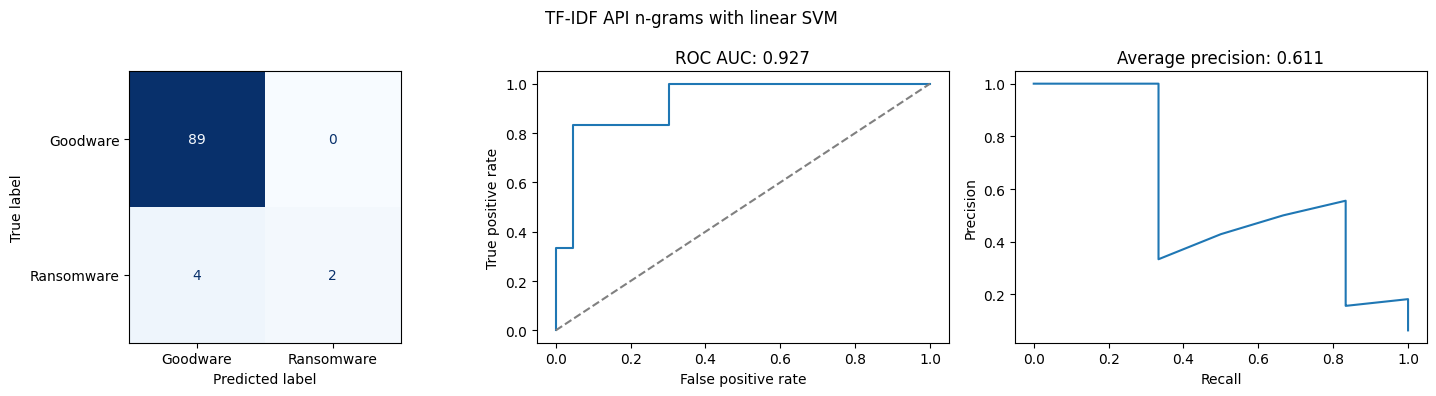

,precision,recall,f1-score,support
goodware,0.956989,1.000000,0.978022,89.000000
ransomware,1.000000,0.333333,0.500000,6.000000
accuracy,0.957895,0.957895,0.957895,0.957895
macro avg,0.978495,0.666667,0.739011,95.000000
weighted avg,0.959706,0.957895,0.947831,95.000000


In [9]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False, token_pattern=r"\S+", ngram_range=(1, 2),
        max_features=5000, sublinear_tf=True,
    )),
    ("classifier", SVC(kernel="linear", class_weight="balanced", random_state=SEED)),
])
svm_model.fit(train["APISEQ"], train["label"])
svm_scores = svm_model.decision_function(test["APISEQ"])
svm_probabilities = 1 / (1 + np.exp(-svm_scores))
svm_metrics = evaluate("TF-IDF API n-grams with linear SVM", test["label"].to_numpy(), svm_probabilities, "svm")
joblib.dump(svm_model, MODELS_DIR / "svm.joblib")
display(pd.DataFrame(svm_metrics["classification_report"]).T)

## 5. Deep-learning model: LSTM

In [10]:
MAX_LENGTH = 100
BATCH_SIZE = 32
counts = Counter(api for sequence in train["APISEQ"] for api in sequence.split())
vocabulary = {"<PAD>": 0, "<UNK>": 1}
vocabulary.update({api: index for index, (api, _) in enumerate(counts.most_common(), 2)})

def encode(sequence):
    tokens = [vocabulary.get(api, 1) for api in sequence.split()[:MAX_LENGTH]]
    length = len(tokens)
    return tokens + [0] * (MAX_LENGTH - length), length

class SequenceDataset(Dataset):
    def __init__(self, frame):
        encoded = [encode(sequence) for sequence in frame["APISEQ"]]
        self.tokens = torch.tensor([item[0] for item in encoded], dtype=torch.long)
        self.lengths = torch.tensor([item[1] for item in encoded], dtype=torch.long)
        self.labels = torch.tensor(frame["label"].to_numpy(), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.tokens[index], self.lengths[index], self.labels[index]

class ApiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(len(vocabulary), 64, padding_idx=0)
        self.lstm = nn.LSTM(64, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.output = nn.Linear(64, 1)

    def forward(self, tokens, lengths):
        sequence, _ = self.lstm(self.embedding(tokens))
        rows = torch.arange(len(lengths), device=tokens.device)
        return self.output(self.dropout(sequence[rows, lengths - 1])).squeeze(1)

def predict(model, loader, device):
    model.eval()
    probabilities, labels = [], []
    with torch.no_grad():
        for tokens, lengths, batch_labels in loader:
            logits = model(tokens.to(device), lengths.to(device))
            probabilities.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(batch_labels.numpy())
    return np.asarray(labels, dtype=int), np.asarray(probabilities)

,epoch,training_loss,validation_f1
0,1,1.289049,0.217391


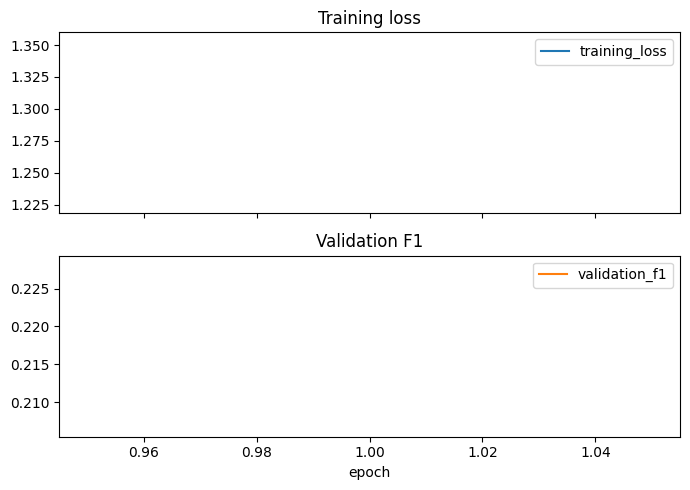

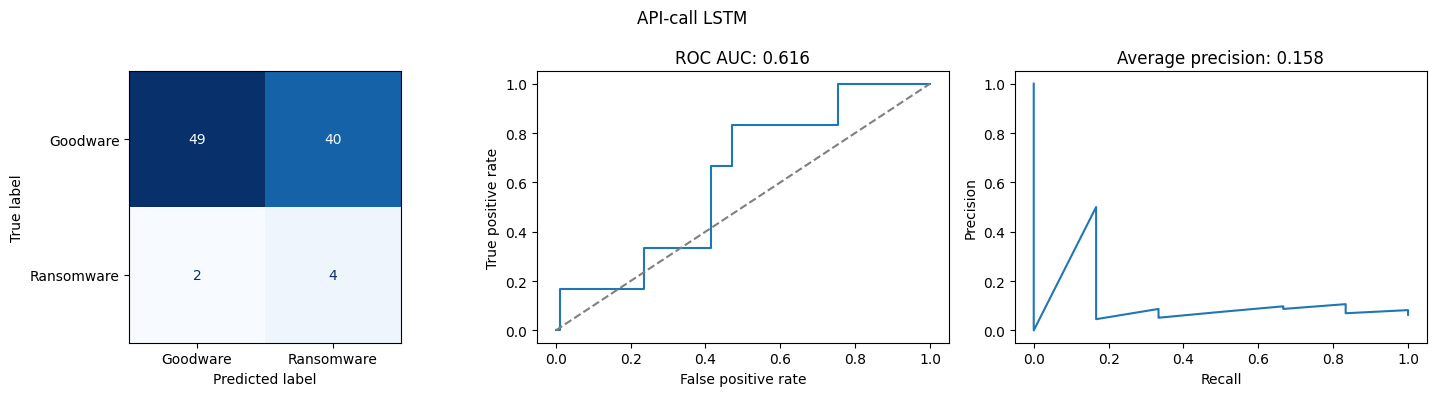

,precision,recall,f1-score,support
goodware,0.960784,0.550562,0.700000,89.000000
ransomware,0.090909,0.666667,0.160000,6.000000
accuracy,0.557895,0.557895,0.557895,0.557895
macro avg,0.525847,0.608614,0.430000,95.000000
weighted avg,0.905845,0.557895,0.665895,95.000000


In [11]:
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(SequenceDataset(train), batch_size=BATCH_SIZE, shuffle=True, generator=generator)
validation_loader = DataLoader(SequenceDataset(validation), batch_size=BATCH_SIZE)
test_loader = DataLoader(SequenceDataset(test), batch_size=BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = ApiLSTM().to(device)
positive_weight = torch.tensor([(len(train) - train["label"].sum()) / train["label"].sum()], device=device)
loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=0.001)

history = []
best_validation_f1 = -1
for epoch in range(1, LSTM_EPOCHS + 1):
    lstm_model.train()
    total_loss = 0
    for tokens, lengths, labels in train_loader:
        tokens, lengths, labels = tokens.to(device), lengths.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = loss_function(lstm_model(tokens, lengths), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)

    validation_labels, validation_probabilities = predict(lstm_model, validation_loader, device)
    validation_f1 = f1_score(validation_labels, validation_probabilities >= 0.5, zero_division=0)
    history.append({"epoch": epoch, "training_loss": total_loss / len(train), "validation_f1": validation_f1})
    if validation_f1 > best_validation_f1:
        best_validation_f1 = validation_f1
        best_state = {name: value.detach().cpu().clone() for name, value in lstm_model.state_dict().items()}

lstm_model.load_state_dict(best_state)
history_frame = pd.DataFrame(history)
display(history_frame)
history_frame.set_index("epoch").plot(subplots=True, figsize=(7, 5), title=["Training loss", "Validation F1"])
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures/lstm-training-history.png", dpi=180)
plt.show()

test_labels, lstm_probabilities = predict(lstm_model, test_loader, device)
lstm_metrics = evaluate("API-call LSTM", test_labels, lstm_probabilities, "lstm")
lstm_metrics.update({"best_validation_f1": float(best_validation_f1),
                     "epochs": LSTM_EPOCHS, "device": str(device)})
(RESULTS_DIR / "metrics/lstm.json").write_text(json.dumps(lstm_metrics, indent=2))
torch.save({"model_state": best_state, "vocabulary": vocabulary}, MODELS_DIR / "lstm.pt")
display(pd.DataFrame(lstm_metrics["classification_report"]).T)

## 6. Compare and export

In [12]:
metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
comparison = pd.DataFrame([
    {"model": "Linear SVM", **{metric: svm_metrics[metric] for metric in metric_names}},
    {"model": "LSTM", **{metric: lstm_metrics[metric] for metric in metric_names}},
])
comparison.to_csv(RESULTS_DIR / "model-comparison.csv", index=False)
(RESULTS_DIR / "run-summary.json").write_text(json.dumps({
    "records_after_deduplication": len(data),
    "train_records": len(train), "validation_records": len(validation), "test_records": len(test),
    "unique_goodware": int((data["label"] == 0).sum()),
    "unique_ransomware": int((data["label"] == 1).sum()),
    "lstm_epochs": LSTM_EPOCHS,
}, indent=2))
display(comparison.style.format({metric: "{:.4f}" for metric in metric_names}).highlight_max(subset=metric_names, color="#d9ead3"))

if COLAB:
    export_dir = ROOT / "section_04_export"
    shutil.copytree(RESULTS_DIR, export_dir / "reports", dirs_exist_ok=True)
    shutil.copytree(MODELS_DIR, export_dir / "models", dirs_exist_ok=True)
    shutil.make_archive("/content/section_04_results", "zip", root_dir=export_dir)

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Linear SVM,0.9579,1.0000,0.3333,0.5000,0.9270,0.6110
1,LSTM,0.5579,0.0909,0.6667,0.1600,0.6161,0.1580


## Interpretation and prevention implications

- Recall measures how much ransomware activity is detected; false negatives represent undetected malicious behavior.
- False positives represent legitimate software that could be blocked or quarantined.
- The SVM uses API-call presence and short transitions, while the LSTM attempts to learn longer ordered behavior.
- The deduplicated ransomware class is very small, so results have high uncertainty and must not be presented as deployment evidence.
- A practical prevention system would combine model alerts with process isolation, protected backups, least privilege, application allow-listing, and human review.